In [1]:
import sys
sys.path.append("../../src/")
from mfmodeling import NARGP
help(NARGP)

Help on class NARGP in module mfmodeling.NARGP_GPyTorch:

class NARGP(builtins.object)
 |  NARGP(data_list)
 |
 |  Nonlinear autoregressive multi-fidelity GP (Perdikaris 2017)
 |  Uses SingleGP at each fidelity level.
 |
 |  Methods defined here:
 |
 |  __init__(self, data_list)
 |      Initialize self.  See help(type(self)) for accurate signature.
 |
 |  optimize(self, verbose=True)
 |
 |  predict(self, x, ifidelity=None, nMonteCarlo=200)
 |
 |  ----------------------------------------------------------------------
 |  Readonly properties defined here:
 |
 |  data_list
 |
 |  model_list
 |
 |  ----------------------------------------------------------------------
 |  Data descriptors defined here:
 |
 |  __dict__
 |      dictionary for instance variables
 |
 |  __weakref__
 |      list of weak references to the object



### Preparation of data set

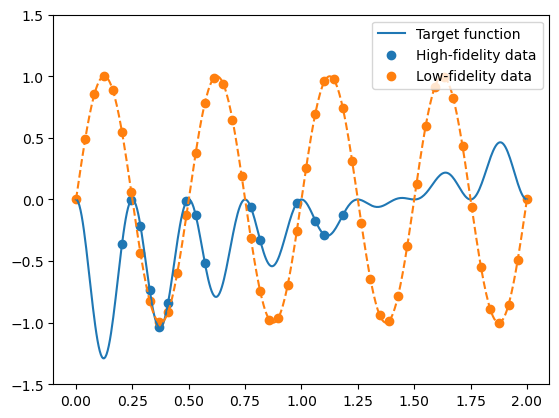

In [2]:
import numpy as np
from matplotlib import pyplot as plt

np.random.seed(24)

''' function definitions '''
def high(x):
    return (x-np.sqrt(2))*low(x)**2
    # return low(x)**2

def low(x):
    return np.sin(4.0*np.pi*x)

''' Define training and test points '''
dim = 1
s = 2
plot = 1
N1 = 50
N2 = np.array([15])

Nts = 400
Xtest = np.linspace(0,2, Nts)[:,None]
Exact= high(Xtest)
Low = low(Xtest)

X1 = np.linspace(0,2, N1)[:,None]
# perm = np.random.permutation(N1)
perm = np.random.permutation(int(N1*0.6))
X2 = X1[perm[0:N2[0]]]

Y1 = low(X1)
Y2 = high(X2)

plt.plot(Xtest,Exact,label="Target function")
plt.plot(Xtest,Low,"--")
plt.scatter(X2,Y2,label="High-fidelity data")
plt.scatter(X1,Y1,label="Low-fidelity data")
plt.legend()
plt.ylim(-1.5,1.5)
plt.show()

In [3]:
data_list = [[X1,Y1], # Low-fidelity data set
             [X2,Y2]] # High-fidelity data set
model_nargp = NARGP(data_list=data_list)
model_nargp.optimize()
mean, var = model_nargp.predict(Xtest)

--- Training NARGP with 2 fidelities ---

[Fidelity 0] Training on 50 points
Restart 1/4, f = -1.4175
Restart 2/4, f = -3.3507
Restart 3/4, f = -3.3507
Restart 4/4, f = -3.3507

[Fidelity 1] Training on 15 points
Restart 1/4, f = -0.9374
Restart 2/4, f = -1.1106
Restart 3/4, f = -1.1106
Restart 4/4, f = -1.1107


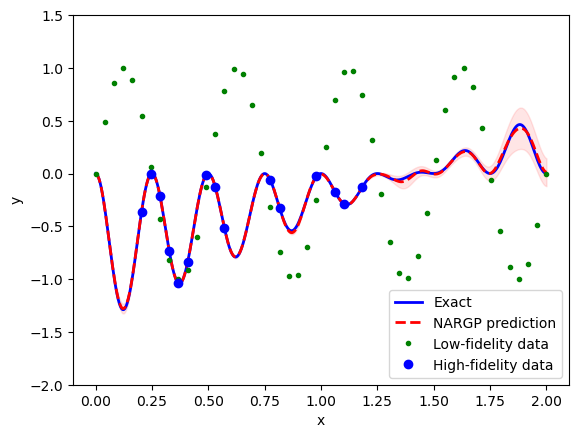

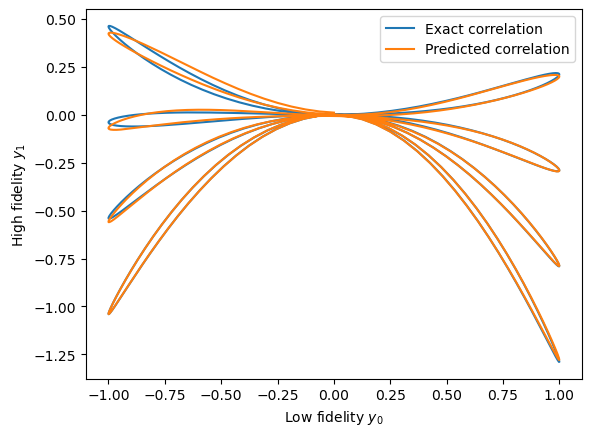

In [4]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(Xtest, Exact, 'b', label='Exact', linewidth = 2)
ax.plot(Xtest, mean, 'r--', label = 'NARGP prediction', linewidth = 2)
ax.fill_between(Xtest.ravel(), (mean-2.0*np.sqrt(var)).ravel(), (mean+2.0*np.sqrt(var)).ravel(), alpha=0.1, color='red')
ax.plot(X1, Y1,'g.', label="Low-fidelity data")
ax.plot(X2, Y2,'bo', label="High-fidelity data")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-2,1.5)
ax.legend()
plt.show()

mean0, var0 = model_nargp.predict(Xtest,ifidelity=0)
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(Low, Exact, label = "Exact correlation")
ax.plot(mean0, mean, label = "Predicted correlation")
ax.set_xlabel(r"Low fidelity $y_0$")
ax.set_ylabel(r"High fidelity $y_1$")
ax.legend()
plt.show()

In [5]:
from mfmodeling import SingleGP
data = [X2,Y2] # Single GP using only high-fidelity data
model_singlegp = SingleGP(data = data)
model_singlegp.optimize()
mean_singlegp, var_singlegp = model_singlegp.predict(Xtest)

Restart 1/4, f = -0.0941
Restart 2/4, f = -0.1130
Restart 3/4, f = -0.1130
Restart 4/4, f = -0.1130


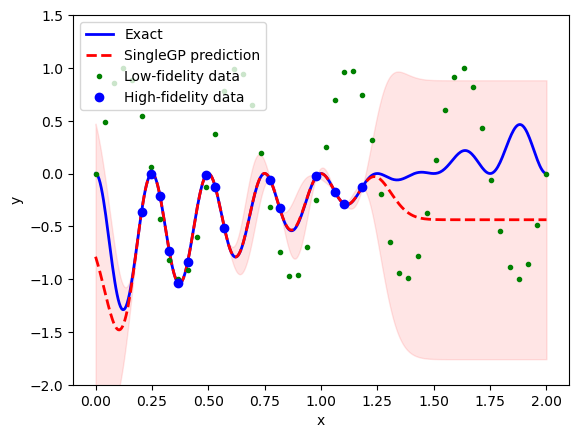

In [6]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(Xtest, Exact, 'b', label='Exact', linewidth = 2)
ax.plot(Xtest, mean_singlegp, 'r--', label = 'SingleGP prediction', linewidth = 2)
ax.fill_between(Xtest.ravel(), (mean_singlegp-2.0*np.sqrt(var_singlegp)).ravel(), (mean_singlegp+2.0*np.sqrt(var_singlegp)).ravel(), alpha=0.1, color='red')
ax.plot(X1, Y1,'g.', label="Low-fidelity data")
ax.plot(X2, Y2,'bo', label="High-fidelity data")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_ylim(-2,1.5)
ax.legend()
plt.show()